
Classified Data by District:
          district    elevation  avg_rainfall severity
0                   1258.451613   1859.652854   Medium
1                    720.000000   1581.500000   Medium
5          Achham   1053.375000   1526.700170   Medium
6     Arghakhachi   1709.500000   2017.764286     High
7    Arghakhachi     467.000000   1560.980952   Medium
..             ...          ...           ...      ...
106       Syangja    985.857143   2710.696327     High
108        Tanahu    630.000000   1944.038095   Medium
109       Tanahun    497.500000   2316.888333     High
112       district          NaN   2019.000000     High
113       kalikot   1729.000000   1629.057143   Medium

[77 rows x 4 columns]

Classified data saved to classified_rainfall_data.csv


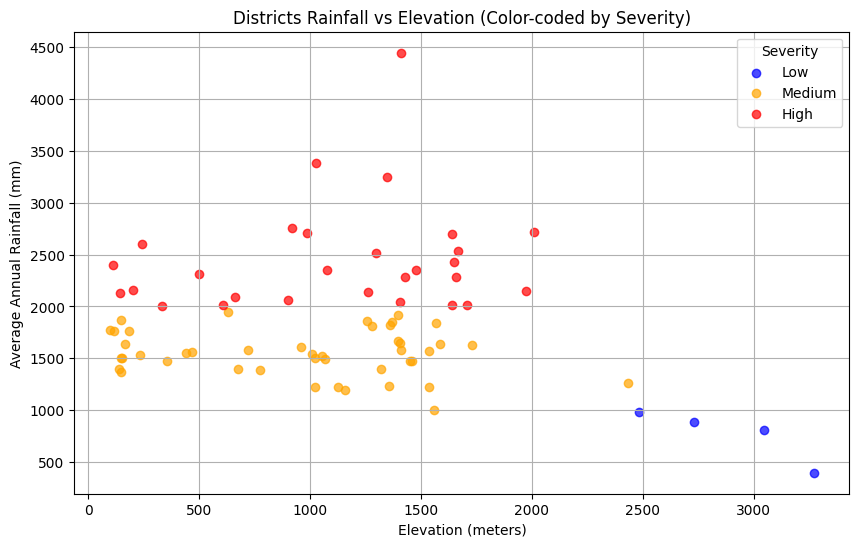

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = "/content/drive/MyDrive/Raindataset.csv"
data = pd.read_csv(file_path)

# Step 2: Data Preprocessing
# Drop rows where all columns are NaN
data = data.dropna(how='all')

# Rename columns for easier access
data.columns = [
    "S.N", "station", "district", "elevation",
    "2016", "2017", "2018", "2019", "2020", "2021", "2022"
]

# Replace 'NA' strings with NaN
data.replace("NA", np.nan, inplace=True)

# Convert numeric columns to float
numeric_columns = ["elevation", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Aggregate rainfall data by district
rainfall_columns = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]

# Calculate average rainfall across years for each district
district_data = (
    data.groupby("district")
    .agg(
        elevation=("elevation", "mean"),  # Average elevation per district
        avg_rainfall=(rainfall_columns[0], "mean")  # Initialize with the first year
    )
    .reset_index()
)

# Add remaining years to calculate the overall average rainfall
for year in rainfall_columns[1:]:
    district_data["avg_rainfall"] += data.groupby("district")[year].mean().values

# Divide by the number of years to get the mean
district_data["avg_rainfall"] /= len(rainfall_columns)

# Handle missing values in avg_rainfall
district_data = district_data.dropna(subset=["avg_rainfall"])

# Define severity based on rainfall thresholds
def classify_severity(rainfall):
    if rainfall < 1000:
        return "Low"
    elif 1000 <= rainfall < 2000:
        return "Medium"
    else:
        return "High"

district_data["severity"] = district_data["avg_rainfall"].apply(classify_severity)

# Step 3: Output the Classified Data
print("\nClassified Data by District:")
print(district_data[["district", "elevation", "avg_rainfall", "severity"]])

# Optional: Save the classified data to a CSV file
output_file = "classified_rainfall_data.csv"
district_data[["district", "elevation", "avg_rainfall", "severity"]].to_csv(output_file, index=False)
print(f"\nClassified data saved to {output_file}")

# Step 4: Visualization
# Scatterplot of districts with rainfall data along elevation
plt.figure(figsize=(10, 6))
colors = {"Low": "blue", "Medium": "orange", "High": "red"}
for severity in colors.keys():
    subset = district_data[district_data["severity"] == severity]
    plt.scatter(
        subset["elevation"],
        subset["avg_rainfall"],
        color=colors[severity],
        label=severity,
        alpha=0.7
    )

plt.title("Districts Rainfall vs Elevation (Color-coded by Severity)")
plt.xlabel("Elevation (meters)")
plt.ylabel("Average Annual Rainfall (mm)")
plt.legend(title="Severity")
plt.grid(True)
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# Step 1: Load the dataset
file_path = "/content/drive/MyDrive/Raindataset.csv"
data = pd.read_csv(file_path)

# Step 2: Data Preprocessing
# Drop rows where all columns are NaN
data = data.dropna(how='all')

# Rename columns for easier access
data.columns = [
    "S.N", "station", "district", "elevation",
    "2016", "2017", "2018", "2019", "2020", "2021", "2022"
]

# Replace 'NA' strings with NaN
data.replace("NA", np.nan, inplace=True)

# Convert numeric columns to float
numeric_columns = ["elevation", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Aggregate rainfall data by district
rainfall_columns = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]

# Calculate average rainfall across years for each district
district_data = (
    data.groupby("district")
    .agg(
        elevation=("elevation", "mean"),  # Average elevation per district
        avg_rainfall=(rainfall_columns[0], "mean")  # Initialize with the first year
    )
    .reset_index()
)

# Add remaining years to calculate the overall average rainfall
for year in rainfall_columns[1:]:
    district_data["avg_rainfall"] += data.groupby("district")[year].mean().values

# Divide by the number of years to get the mean
district_data["avg_rainfall"] /= len(rainfall_columns)

# Handle missing values in avg_rainfall
district_data = district_data.dropna(subset=["avg_rainfall"])

# Define severity based on rainfall thresholds
def classify_severity(rainfall):
    if rainfall < 1000:
        return "Low"
    elif 1000 <= rainfall < 2000:
        return "Medium"
    else:
        return "High"

# Encode severity labels
severity_mapping = {"Low": 0, "Medium": 1, "High": 2}

# Add severity column
district_data.loc[:, "severity"] = district_data["avg_rainfall"].apply(classify_severity)
district_data.loc[:, "severity_encoded"] = district_data["severity"].map(severity_mapping)

# Check class distribution
print("Class Distribution:")
print(district_data["severity_encoded"].value_counts())

# Features and target
X = district_data[["elevation", "avg_rainfall"]]
y = district_data["severity_encoded"]

# Handle missing values in X
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression Classifier with balanced class weights
clf = LogisticRegression(random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# Evaluate the model
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Class Distribution:
severity_encoded
1    44
2    29
0     4
Name: count, dtype: int64
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1: Load the dataset
file_path = "/content/drive/MyDrive/Raindataset.csv"
data = pd.read_csv(file_path)

# Step 2: Data Preprocessing
# Drop rows where all columns are NaN
data = data.dropna(how='all')

# Rename columns for easier access
data.columns = [
    "S.N", "station", "district", "elevation",
    "2016", "2017", "2018", "2019", "2020", "2021", "2022"
]

# Replace 'NA' strings with NaN
data.replace("NA", np.nan, inplace=True)

# Convert numeric columns to float
numeric_columns = ["elevation", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Aggregate rainfall data by district
rainfall_columns = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]

# Calculate average rainfall across years for each district
district_data = (
    data.groupby("district")
    .agg(
        elevation=("elevation", "mean"),  # Average elevation per district
        avg_rainfall=(rainfall_columns[0], "mean")  # Initialize with the first year
    )
    .reset_index()
)

# Add remaining years to calculate the overall average rainfall
for year in rainfall_columns[1:]:
    district_data["avg_rainfall"] += data.groupby("district")[year].mean().values

# Divide by the number of years to get the mean
district_data["avg_rainfall"] /= len(rainfall_columns)

# Handle missing values in avg_rainfall
district_data = district_data.dropna(subset=["avg_rainfall"])

# Define severity based on rainfall thresholds
def classify_severity(rainfall):
    if rainfall < 1000:
        return "Low"
    elif 1000 <= rainfall < 2000:
        return "Medium"
    else:
        return "High"

# Encode severity labels
severity_mapping = {"Low": 0, "Medium": 1, "High": 2}

# Add severity column
district_data.loc[:, "severity"] = district_data["avg_rainfall"].apply(classify_severity)
district_data.loc[:, "severity_encoded"] = district_data["severity"].map(severity_mapping)

# Features and target
X = district_data[["elevation", "avg_rainfall"]]
y = district_data["severity_encoded"]

# Handle missing values in X
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle imbalanced classes using SMOTE with reduced n_neighbors
smote = SMOTE(random_state=42, k_neighbors=3)  # Reduce n_neighbors
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 3: Train and Evaluate Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

# Step 4: Train and Evaluate Random Forest
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Step 5: Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_logreg = cross_val_score(logreg, X_resampled, y_resampled, cv=cv, scoring="accuracy")
cv_scores_rf = cross_val_score(rf, X_resampled, y_resampled, cv=cv, scoring="accuracy")

print("\nCross-Validation Scores:")
print("Logistic Regression CV Accuracy:", np.mean(cv_scores_logreg))
print("Random Forest CV Accuracy:", np.mean(cv_scores_rf))

Logistic Regression Performance:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



Random Forest Performance:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27


Cross-Validation Scores:
Logistic Regression CV Accuracy: 0.9700854700854702
Random Forest CV Accuracy: 0.9925925925925926


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define the models
logreg = LogisticRegression(random_state=42, max_iter=10000)
rf = RandomForestClassifier(random_state=42)

# Define hyper-parameter grids
logreg_param_grid = {
    'C': [0.1, 1, 10],  # Regularization strength
    'solver': ['liblinear', 'lbfgs']  # Optimization algorithm
}

rf_param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]  # Minimum samples required to split a node
}

# Perform Grid Search with Cross-Validation
logreg_grid = GridSearchCV(logreg, logreg_param_grid, cv=5, scoring='accuracy')
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy')

# Fit the models
logreg_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)

# Get the best hyper-parameters
print("Best Hyper-parameters for Logistic Regression:", logreg_grid.best_params_)
print("Best Hyper-parameters for Random Forest:", rf_grid.best_params_)

# Evaluate the best models on the test set
logreg_best = logreg_grid.best_estimator_
rf_best = rf_grid.best_estimator_

print("Logistic Regression Test Accuracy:", logreg_best.score(X_test, y_test))
print("Random Forest Test Accuracy:", rf_best.score(X_test, y_test))

Best Hyper-parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}
Best Hyper-parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Logistic Regression Test Accuracy: 1.0
Random Forest Test Accuracy: 1.0
